## **RMS Titanic**
![image](https://upload.wikimedia.org/wikipedia/commons/f/fd/RMS_Titanic_3.jpg)

## Brief History
RMS Titanic was a British passenger liner that sank in the North Atlantic Ocean in 1912, after colliding with an iceberg during her maiden voyage from Southampton to New York City. Of the estimated **2,224 passengers** and crew aboard, more than **1,500 died**, making it one of modern history's deadliest commercial marine disasters during peacetime. RMS Titanic was the largest ship afloat at the time she entered service and was the second of three Olympic-class ocean liners operated by the White Star Line. She was built by the Harland and Wolff shipyard in Belfast. Thomas Andrews, chief naval architect of the shipyard at the time, died in the disaster.

Titanic was under the command of Capt. Edward Smith, who also went down with the ship.  Although Titanic had advanced safety features such as watertight compartments and remotely activated watertight doors, it only carried enough lifeboats for 1,178 people—about half the number on board, and one third of her total capacity—due to outdated maritime safety regulations. The ship carried 16 lifeboat davits which could lower three lifeboats each, for a total of 48 boats. However, Titanic carried only a total of 20 lifeboats, four of which were collapsible and proved hard to launch during the sinking.

After leaving Southampton on 10 April 1912, Titanic called at Cherbourg in France and Queenstown (now Cobh) in Ireland before heading west to New York. On 14 April, four days into the crossing and about 375 miles (600 km) south of Newfoundland, she **hit an iceberg at 11:40 p.m. ship's time**.

## Setting Up

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn import svm
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
import tensorflow as tf 
%matplotlib inline
import warnings;
warnings.filterwarnings("ignore");
import os
print(os.listdir("../input"))

['gender_submission.csv', 'test.csv', 'train.csv']


## Importing Data

In [2]:
data = pd.read_csv("../input/train.csv")
test_sur = pd.read_csv("../input/gender_submission.csv")
test = pd.read_csv("../input/test.csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
PassengerId    891 non-null int64
Survived       891 non-null int64
Pclass         891 non-null int64
Name           891 non-null object
Sex            891 non-null object
Age            714 non-null float64
SibSp          891 non-null int64
Parch          891 non-null int64
Ticket         891 non-null object
Fare           891 non-null float64
Cabin          204 non-null object
Embarked       889 non-null object
dtypes: float64(2), int64(5), object(5)
memory usage: 83.6+ KB


In [5]:
data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

So our data has some missing values.
Lets visualize them.

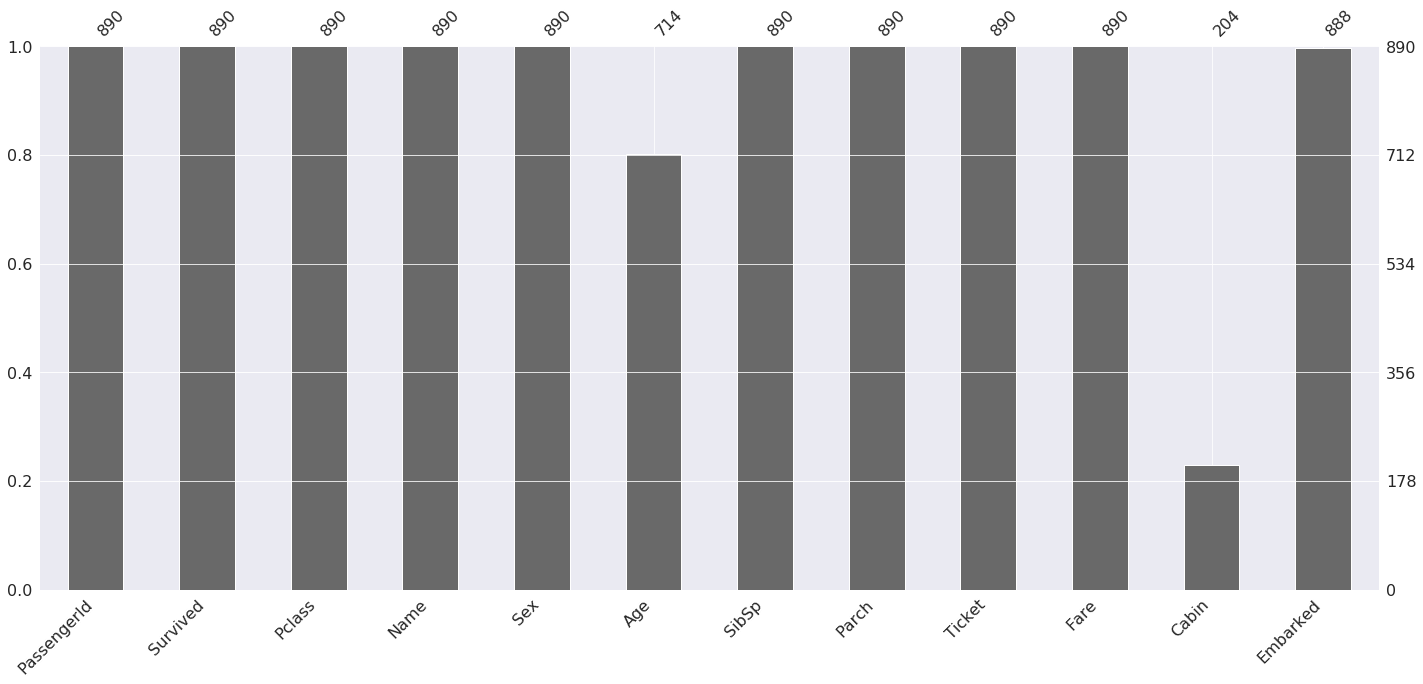

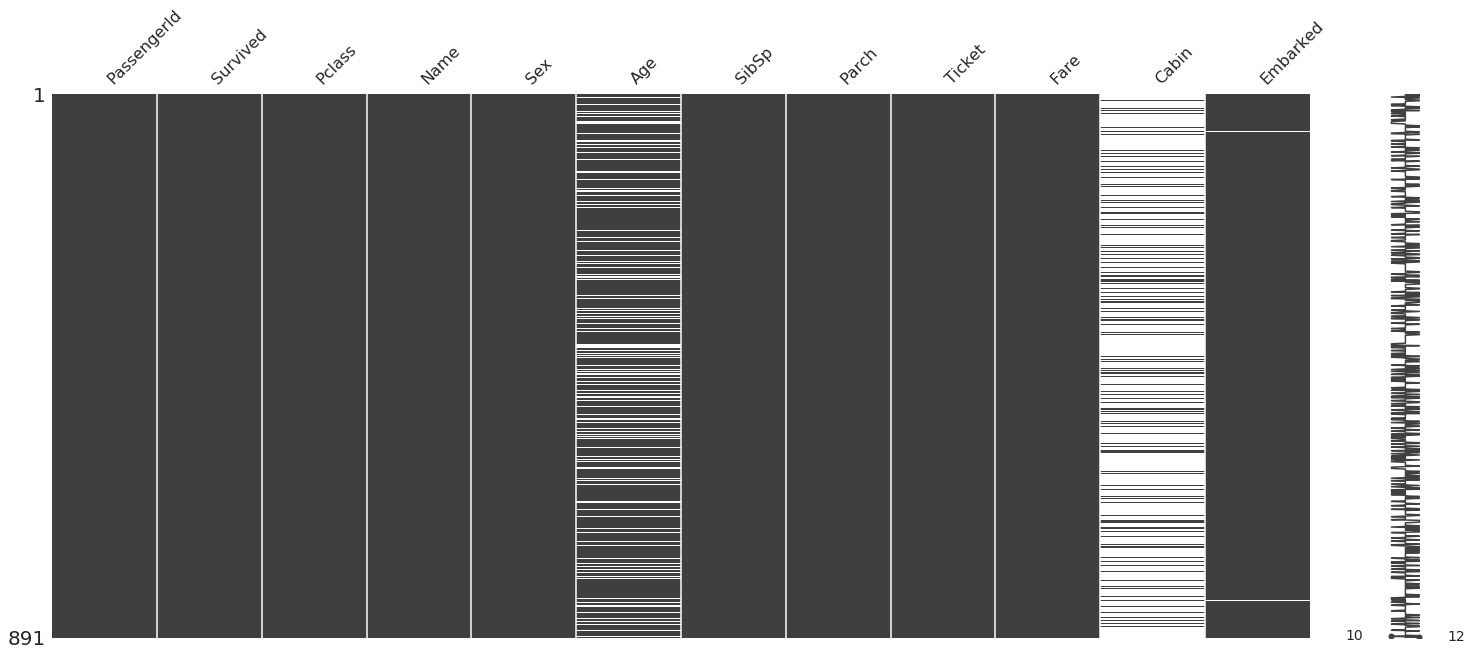

In [6]:
import missingno as msno
msno.bar(data.sample(890))
msno.matrix(data)

## Lets handle these missing values(Data Preprocessing)

Removing name, ticket number and passengerid as they are not important features in predicting if a passenger will die or survive.
Also removing cabin no because it contains a lot of nan values.

In [7]:
data = data.drop(columns = ['Name','Ticket','Cabin','PassengerId'])
data['Age'][np.isnan(data['Age'])] = np.nanmedian(data['Age'])
data = data.dropna()

In [8]:
test_sur.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [9]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [10]:
test = test.drop(columns = ['Name','Ticket','Cabin','PassengerId'])
test['Age'][np.isnan(test['Age'])] = np.nanmedian(test['Age'])
test['Fare'][np.isnan(test['Fare'])] = np.nanmedian(test['Fare'])
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,34.5,0,0,7.8292,Q
1,3,female,47.0,1,0,7.0000,S
2,2,male,62.0,0,0,9.6875,Q
3,3,male,27.0,0,0,8.6625,S
4,3,female,22.0,1,1,12.2875,S


In [11]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


That looks much better!

## Getting Some Insights From The Data

lets see some basic correlations in out data.

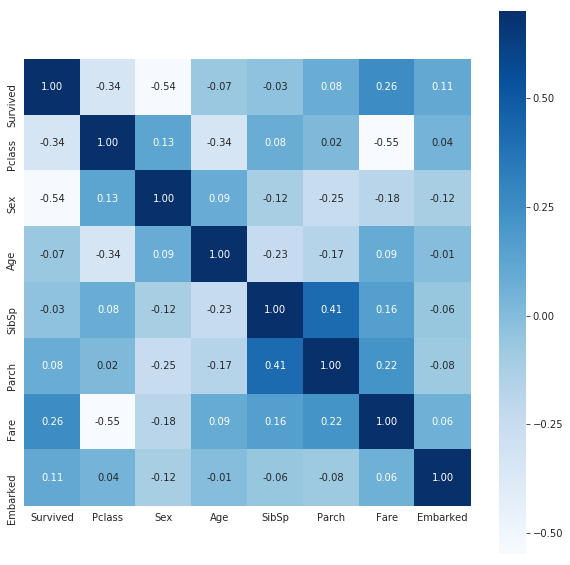

In [12]:
test_df = data.copy()
map1 = {"female":0 , "male":1}
map2 = {"S":0 , "C":1 , "Q":2}
test_df['Sex']=test_df.Sex.map(map1)
test_df["Embarked"] = test_df.Embarked.map(map2)
corr_map = test_df.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_map,vmax=.7, square=True,annot=True,fmt=".2f",cmap='Blues')

### Some important inferences.
* Fare and passenger class have a negative correlation. It means that as fare increases class becomes better.
* Fare and survival have some positive correlation meaning rich have more probability of survival, or maybe they were preferred during evacuation.
* No of siblings and no of parents on board have a high correlation.
* Fare and Parch are correlated meaning that those travelling with there children or parents prefer higher class compartments.
* Female had more probability of having parents or children onboard.
* Younger travellers had more no of siblings or spouse on board for obvious reasons.
* Age and Pclass have -ve correlation meaning older travellers preferred better class.
* Female passengers have a very high chance of survival than male passengers meaning female passengers were preferred during evacuation.
* Also pclass and survival are correlated meaning elite passengers were preferred during evacuation.

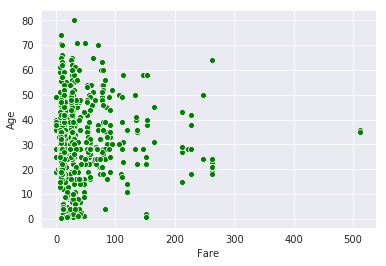

In [13]:
sns.scatterplot(data["Fare"],data["Age"],color='Green')

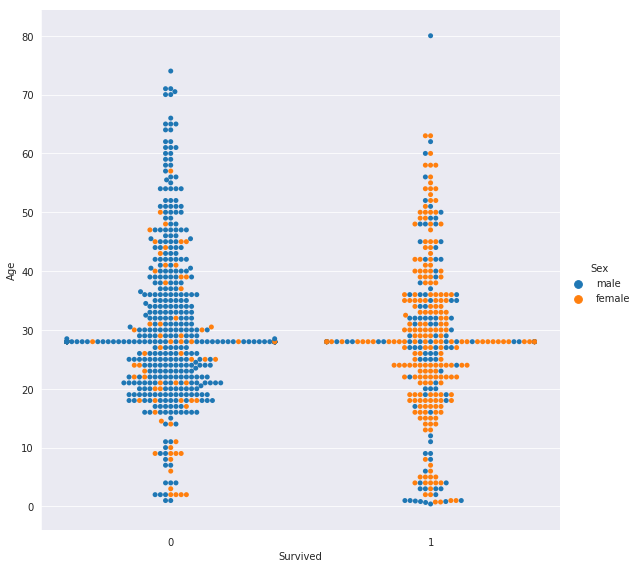

In [14]:
sns.catplot(x="Survived", y="Age", hue="Sex", kind="swarm", data=data, aspect=1,height=8);

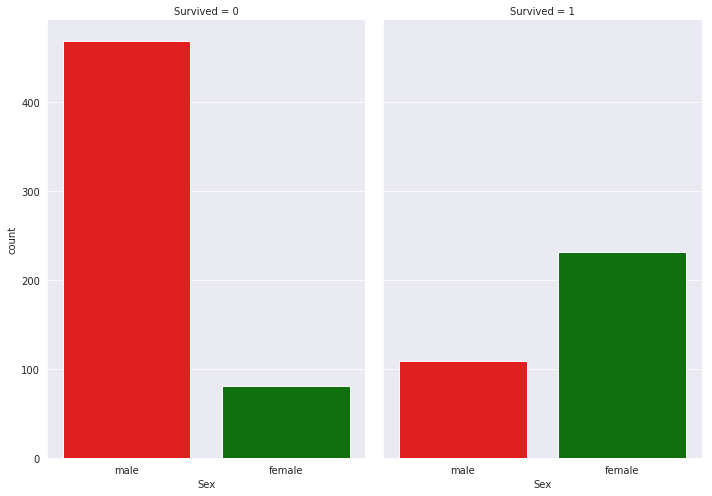

In [15]:
sns.factorplot(x="Sex",col="Survived", data=data , kind="count",size=7, aspect=.7,palette=['red','green'])

### It is clearly visible from above 2 plots that mostly female passengers and specially younger girls were the most prefered during evacution.

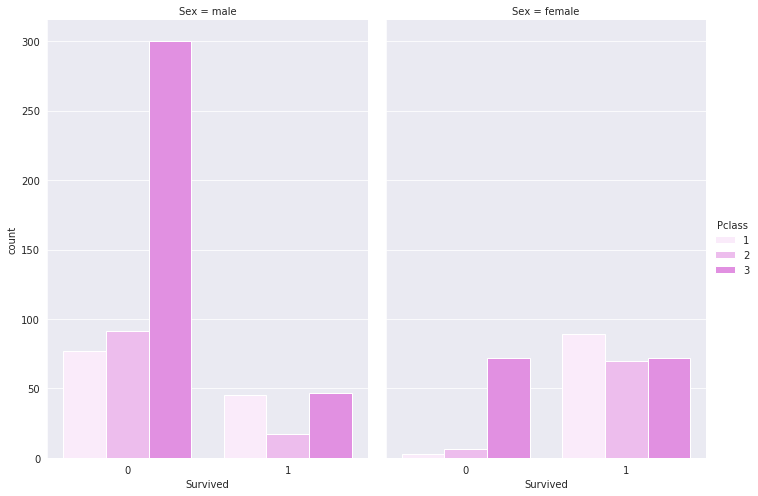

In [16]:
sns.catplot(x="Survived",hue="Pclass", kind="count",col='Sex', data=data,color='Violet',aspect=0.7,height=7);

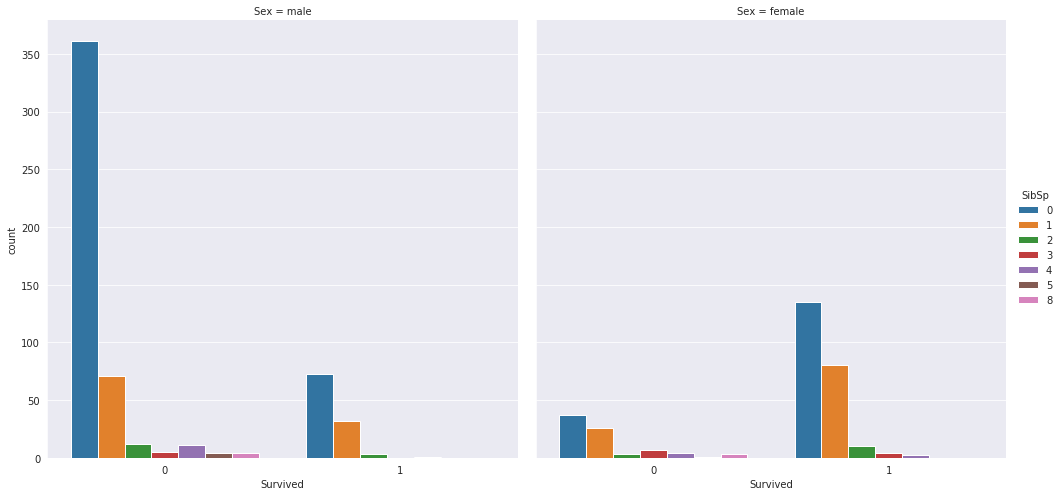

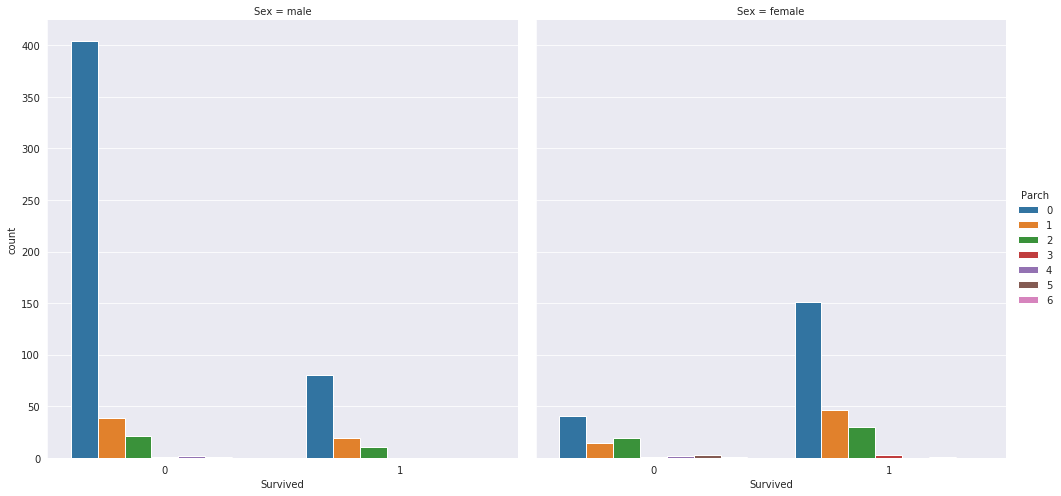

In [17]:
sns.catplot(x="Survived", hue="SibSp", col = 'Sex',kind="count", data=data,height=7);
sns.catplot(x="Survived", hue="Parch", col = 'Sex', kind="count", data=data,height=7);

Now, this gives a very good insight about family and gender relations.
Female passengers were helped by there family males so they have higher survival rate in case if there family is onboard.
But it was just the opposite for males as they were not prefered and thus most of them died saving there families.

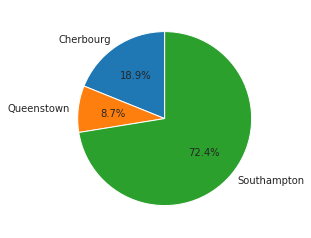

In [18]:
emb =data.groupby('Embarked').size()

plt.pie(emb.values,labels = ["Cherbourg","Queenstown","Southampton"],startangle=90,autopct='%1.1f%%');

#### Most of the passengers were from Southampton. Also Southampton was the starting port of its journey.
![image](https://titanicfacts.net/wp-content/uploads/2018/06/titanic-maiden-voyage-route.gif)

In [19]:
pd.crosstab([data.Sex,data.Survived],data.Pclass, margins=True).style.background_gradient(cmap='gist_rainbow')

In [20]:
data.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,889.000000,889.000000,889.000000,889.000000,889.000000,889.000000
mean,0.382452,2.311586,29.315152,0.524184,0.382452,32.096681
std,0.486260,0.834700,12.984932,1.103705,0.806761,49.697504
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,22.000000,0.000000,0.000000,7.895800
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


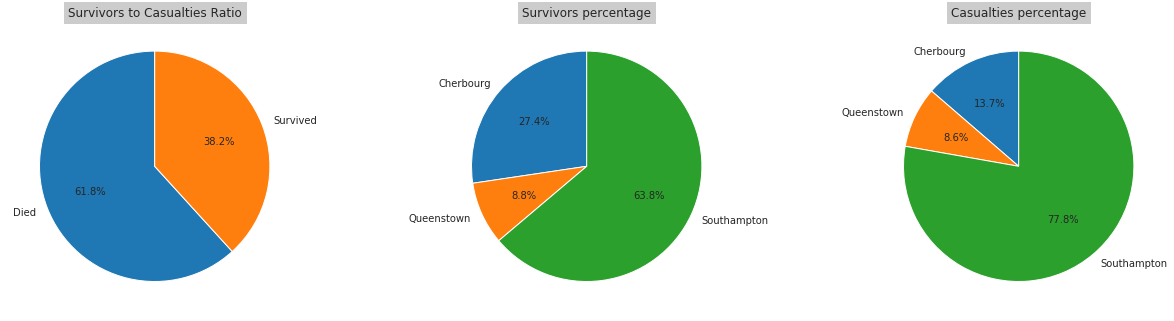

In [21]:
surv =data.groupby('Survived').size()
emb_sur = data[data['Survived']==1].groupby('Embarked').size()
emb_die = data[data['Survived']==0].groupby('Embarked').size()

pie_index = ['Cherbourg','Queenstown','Southampton']

fig = plt.figure()

ax1 = fig.add_axes([0, 0, 1, 1], aspect=1)
ax1.pie(surv.values,labels=['Died','Survived'],startangle=90,autopct='%1.1f%%')
plt.title('Survivors to Casualties Ratio',bbox={'facecolor':'0.8', 'pad':5})

ax2 = fig.add_axes([1, 0, 1, 1], aspect=1)
plt.title('Survivors percentage',bbox={'facecolor':'0.8', 'pad':5})
ax2.pie(emb_sur.values,labels = pie_index,startangle = 90, autopct='%1.1f%%')

ax3 = fig.add_axes([2, 0, 1, 1], aspect=1)
plt.title('Casualties percentage',bbox={'facecolor':'0.8', 'pad':5})
ax3.pie(emb_die.values,labels = pie_index,startangle = 90, autopct='%1.1f%%')

plt.show()      

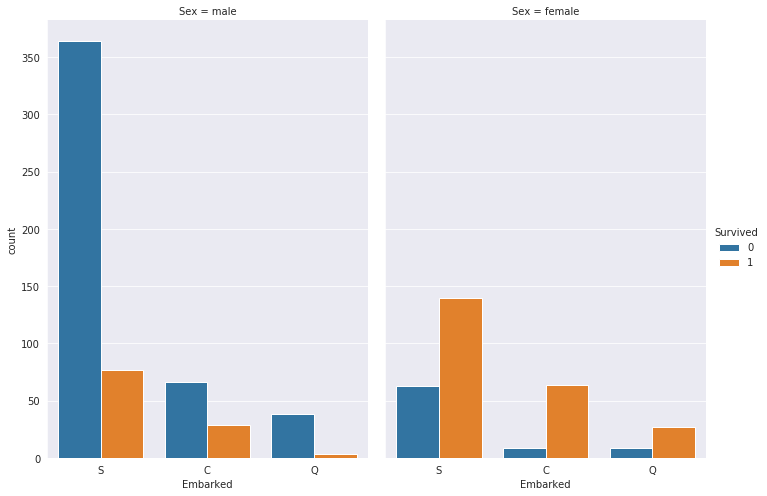

In [22]:
sns.catplot(x="Embarked",hue="Survived", kind="count",col='Sex', data=data,aspect=0.7,height=7);

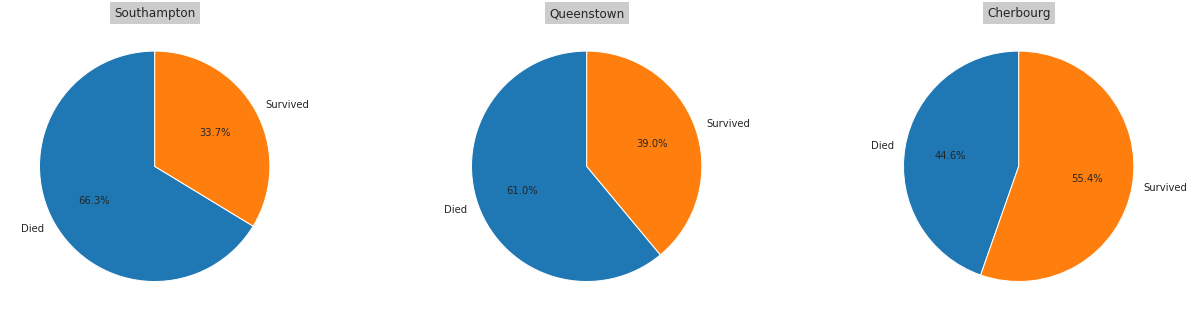

In [23]:
emb_smt = data[data['Embarked']=='S'].groupby('Survived').size()
emb_que = data[data['Embarked']=='Q'].groupby('Survived').size()
emb_che = data[data['Embarked']=='C'].groupby('Survived').size()

fig = plt.figure()
ax1 = fig.add_axes([0, 0, 1,1], aspect=1)
ax1.pie(emb_smt.values,labels = ['Died','Survived'],startangle = 90, autopct='%1.1f%%')
plt.title('Southampton',bbox={'facecolor':'0.8', 'pad':5})
ax2 = fig.add_axes([1, 0, 1,1], aspect=1)
ax2.pie(emb_que.values,labels = ['Died','Survived'],startangle = 90, autopct='%1.1f%%')
plt.title('Queenstown',bbox={'facecolor':'0.8', 'pad':5})
ax3 = fig.add_axes([2,0, 1,1], aspect=1)
ax3.pie(emb_che.values,labels = ['Died','Survived'],startangle = 90, autopct='%1.1f%%')
plt.title('Cherbourg',bbox={'facecolor':'0.8', 'pad':5})
plt.show()      

### From the above Pie charts it could be seen that, opposing the general trend, Cherbourg has more survivors than casualties. Whereas Southampton has most no of casualties.
This could be because of many reasons: 
* One of them could be that some are better swimmers.
* Other could be that passengers from Cherbourg have more no of female passengers.

## Training on different models.

In [24]:
#Converting text data to numerical
map1 = {"female":0 , "male":1}
map2 = {"S":0 , "C":1 , "Q":2}
data['Sex']=data.Sex.map(map1)
data["Embarked"] = data.Embarked.map(map2)
test['Sex']=test.Sex.map(map1)
test["Embarked"] = test.Embarked.map(map2)
#one hot encoding
data = pd.get_dummies(data)
test = pd.get_dummies(test)

In [25]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,0
1,1,1,0,38.0,1,0,71.2833,1
2,1,3,0,26.0,0,0,7.9250,0
3,1,1,0,35.0,1,0,53.1000,0
4,0,3,1,35.0,0,0,8.0500,0


In [26]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,34.5,0,0,7.8292,2
1,3,0,47.0,1,0,7.0000,0
2,2,1,62.0,0,0,9.6875,2
3,3,1,27.0,0,0,8.6625,0
4,3,0,22.0,1,1,12.2875,0


### Now lets create some creative new features using the existing ones.

In [27]:
data['Family'] = data.Parch+data.SibSp
data.Age = data.Age/np.mean(data.Age)
data.Fare = data.Fare/np.mean(data.Fare)
test['Family'] = test.Parch+test.SibSp
test.Age = test.Age/np.mean(test.Age)
test.Fare = test.Fare/np.mean(test.Fare)

In [28]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family
0,0,3,1,0.750465,1,0,0.225880,0,1
1,1,1,0,1.296258,1,0,2.220893,1,1
2,1,3,0,0.886913,0,0,0.246910,0,0
3,1,1,0,1.193922,1,0,1.654377,0,1
4,0,3,1,1.193922,0,0,0.250805,0,0


In [29]:
test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Family
0,3,1,1.165569,0,0,0.220066,2,0
1,3,0,1.587876,1,0,0.196759,0,1
2,2,1,2.094645,0,0,0.272300,2,0
3,3,1,0.912184,0,0,0.243489,0,0
4,3,0,0.743261,1,1,0.345382,0,2


In [30]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(data.iloc[:,1:],data.iloc[:,0],test_size=0.2)
#using 70:30 split.

In [31]:
print(x_train.head())
print(y_train.head())

     Pclass  Sex       Age  SibSp  Parch      Fare  Embarked  Family
121       3    1  0.955137      0      0  0.250805         0       0
338       3    1  1.535042      0      0  0.250805         0       0
631       3    1  1.739715      0      0  0.219780         0       0
163       3    1  0.579905      0      0  0.269888         0       0
483       3    0  2.149059      0      0  0.298707         0       0
121    0
338    1
631    0
163    0
483    1
Name: Survived, dtype: int64


In [32]:
classifiers=[['Logistic Regression :',LogisticRegressionCV()],
             ['SVM:',svm.LinearSVC()],
       ['Decision Tree Classification :',DecisionTreeClassifier()],
       ['Random Forest Classification :',RandomForestClassifier()],
       ['Gradient Boosting Classification :', GradientBoostingClassifier()],
       ['Ada Boosting Classification :',AdaBoostClassifier()],
       ['Extra Tree Classification :', ExtraTreesClassifier()],
       ['K-Neighbors Classification :',KNeighborsClassifier()],
       ['Support Vector Classification :',SVC()],
       ['Gaussian Naive Bayes :',GaussianNB()]]
cla_pred=[]
for name,model in classifiers:
    model=model
    model.fit(x_train,y_train)
    predictions = model.predict(x_test)
    cla_pred.append(accuracy_score(y_test,predictions))
    print(name,accuracy_score(y_test,predictions))

Logistic Regression : 0.7808988764044944
SVM: 0.7921348314606742
Decision Tree Classification : 0.7808988764044944
Random Forest Classification : 0.7696629213483146
Gradient Boosting Classification : 0.8033707865168539
Ada Boosting Classification : 0.7921348314606742
Extra Tree Classification : 0.7640449438202247
K-Neighbors Classification : 0.7752808988764045
Support Vector Classification : 0.8089887640449438
Gaussian Naive Bayes : 0.7696629213483146


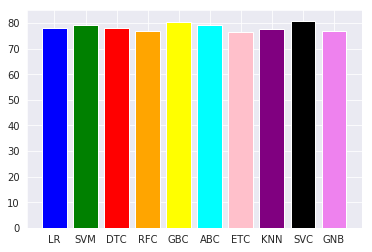

In [33]:
plt.bar(x=[1,2,3,4,5,6,7,8,9,10], height=np.multiply(cla_pred,100)
        ,tick_label=['LR','SVM','DTC', 'RFC', 'GBC', 'ABC', 'ETC', 'KNN', 'SVC','GNB']
        , color=["Blue","Green","red","orange","Yellow","cyan","pink","purple","black","violet"])
plt.show()

## Lets try Neural Networks to get a better classifier 

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import keras
from sklearn import preprocessing

Using TensorFlow backend.


In [35]:
train = pd.read_csv("../input/train.csv")
test = pd.read_csv("../input/test.csv")
gen_sub = pd.read_csv("../input/gender_submission.csv")

In [36]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [37]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [38]:
gen_sub.head()

,PassengerId,Survived
0,892,0
1,893,1
2,894,0
3,895,0
4,896,1


In [39]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Name           418 non-null object
Sex            418 non-null object
Age            332 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Ticket         418 non-null object
Fare           417 non-null float64
Cabin          91 non-null object
Embarked       418 non-null object
dtypes: float64(2), int64(4), object(5)
memory usage: 36.0+ KB


In [40]:
#removing non useful columns
#train
train_clean = train.iloc[:,[1,2,4,5,6,7,9,11]]
# train_clean['Sex'].replace('male', 0,inplace=True)
# train_clean['Sex'].replace('female', 1,inplace=True)
train_clean['Sex'] = train_clean['Sex'].astype('category')
train_clean['Sex'] = train_clean['Sex'].cat.codes
# train_clean['Embarked'].replace('S', 0,inplace=True)
# train_clean['Embarked'].replace('C', 1,inplace=True)
# train_clean['Embarked'].replace('Q', 2,inplace=True)
train_clean.reset_index(inplace=True, drop = True)
train_clean = train_clean[train_clean['Embarked'].notna()]
categorical = ['Embarked']

for var in categorical:
    train_clean = pd.concat([train_clean, 
                    pd.get_dummies(train_clean[var], prefix=var)], axis=1)
    del train_clean[var]
train_clean.reset_index(inplace=True, drop = True)
train_clean['Age'].fillna(train_clean['Age'].mean(), inplace=True)
train_clean.reset_index(inplace=True, drop = True)
train_clean['Family_Size']= train_clean['SibSp']+train_clean['Parch']




#test
test_clean = test.iloc[:,[0,1,3,4,5,6,8,10]]
# test_clean['Sex'].replace('male', 0,inplace=True)
# test_clean['Sex'].replace('female', 1,inplace=True)
test_clean['Sex'] = test_clean['Sex'].astype('category')
test_clean['Sex'] = test_clean['Sex'].cat.codes
# test_clean['Embarked'].replace('S', 0,inplace=True)
# test_clean['Embarked'].replace('C', 1,inplace=True)
# test_clean['Embarked'].replace('Q', 2,inplace=True)
test_clean.reset_index(inplace=True, drop = True)
test_clean = test_clean[test_clean['Embarked'].notna()]
categorical = ['Embarked']

for var in categorical:
    test_clean = pd.concat([test_clean, 
                    pd.get_dummies(test_clean[var], prefix=var)], axis=1)
    del test_clean[var]
    
test_clean.reset_index(inplace=True, drop = True)
test_clean['Age'].fillna(test_clean['Age'].mean(), inplace=True)
test_clean['Fare'].fillna(test_clean['Fare'].mean(), inplace=True)
test_clean.reset_index(inplace=True, drop = True)
test_clean['Family_Size']= test_clean['SibSp']+test_clean['Parch']

In [41]:
train_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Family_Size
0,0,3,1,22.0,1,0,7.2500,0,0,1,1
1,1,1,0,38.0,1,0,71.2833,1,0,0,1
2,1,3,0,26.0,0,0,7.9250,0,0,1,0
3,1,1,0,35.0,1,0,53.1000,0,0,1,1
4,0,3,1,35.0,0,0,8.0500,0,0,1,0


In [42]:
train_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 889 entries, 0 to 888
Data columns (total 11 columns):
Survived       889 non-null int64
Pclass         889 non-null int64
Sex            889 non-null int8
Age            889 non-null float64
SibSp          889 non-null int64
Parch          889 non-null int64
Fare           889 non-null float64
Embarked_C     889 non-null uint8
Embarked_Q     889 non-null uint8
Embarked_S     889 non-null uint8
Family_Size    889 non-null int64
dtypes: float64(2), int64(5), int8(1), uint8(3)
memory usage: 52.2 KB


In [43]:
test_clean.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Family_Size
0,892,3,1,34.5,0,0,7.8292,0,1,0,0
1,893,3,0,47.0,1,0,7.0000,0,0,1,1
2,894,2,1,62.0,0,0,9.6875,0,1,0,0
3,895,3,1,27.0,0,0,8.6625,0,0,1,0
4,896,3,0,22.0,1,1,12.2875,0,0,1,2


In [44]:
test_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
PassengerId    418 non-null int64
Pclass         418 non-null int64
Sex            418 non-null int8
Age            418 non-null float64
SibSp          418 non-null int64
Parch          418 non-null int64
Fare           418 non-null float64
Embarked_C     418 non-null uint8
Embarked_Q     418 non-null uint8
Embarked_S     418 non-null uint8
Family_Size    418 non-null int64
dtypes: float64(2), int64(5), int8(1), uint8(3)
memory usage: 24.6 KB


In [45]:
# #Let's normalize these dataframe

# x = train_clean.values #returns a numpy array
# min_max_scaler = preprocessing.MinMaxScaler()
# x_scaled = min_max_scaler.fit_transform(x)
# train_clean = pd.DataFrame(x_scaled,columns=train_clean.columns)

# x = test_clean.values #returns a numpy array
# min_max_scaler = preprocessing.MinMaxScaler()
# x_scaled = min_max_scaler.fit_transform(x)
# test_clean = pd.DataFrame(x_scaled,columns=test_clean.columns)
from sklearn.preprocessing import StandardScaler

continuous = ['Age', 'Fare', 'Parch', 'Pclass', 'SibSp', 'Family_Size']

scaler = StandardScaler()

for var in continuous:
    train_clean[var] = train_clean[var].astype('float64')
    train_clean[var] = scaler.fit_transform(train_clean[var].values.reshape(-1, 1))

for var in continuous:
    test_clean[var] = test_clean[var].astype('float64')
    test_clean[var] = scaler.fit_transform(test_clean[var].values.reshape(-1, 1))

In [46]:
train_clean.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Family_Size
0,0,0.825209,1,-0.589620,0.431350,-0.474326,-0.500240,0,0,1,0.057853
1,1,-1.572211,0,0.644848,0.431350,-0.474326,0.788947,1,0,0,0.057853
2,1,0.825209,0,-0.281003,-0.475199,-0.474326,-0.486650,0,0,1,-0.561804
3,1,-1.572211,0,0.413385,0.431350,-0.474326,0.422861,0,0,1,0.057853
4,0,0.825209,1,0.413385,-0.475199,-0.474326,-0.484133,0,0,1,-0.561804


In [47]:
test_clean.head()

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_C,Embarked_Q,Embarked_S,Family_Size
0,892,0.873482,1,0.334993,-0.499470,-0.400248,-0.498407,0,1,0,-0.553443
1,893,0.873482,0,1.325530,0.616992,-0.400248,-0.513274,0,0,1,0.105643
2,894,-0.315819,1,2.514175,-0.499470,-0.400248,-0.465088,0,1,0,-0.553443
3,895,0.873482,1,-0.259330,-0.499470,-0.400248,-0.483466,0,0,1,-0.553443
4,896,0.873482,0,-0.655545,0.616992,0.619896,-0.418471,0,0,1,0.764728


## Model Creation

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(train_clean.iloc[:,1:],train_clean.iloc[:,0],test_size=0.2)

In [49]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Activation,Dropout

def clf_model():
    model=Sequential()
    model.add(Dense(10,input_dim=10,kernel_initializer='normal',activation='relu'))
    model.add(Dense(16,activation='relu'))
    model.add(Dense(32,activation='relu'))
    model.add(Dense(16,activation='relu'))
    model.add(Dense(1,activation='relu'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

model = clf_model()

Instructions for updating:
Colocations handled automatically by placer.


In [50]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 10)                110       
_________________________________________________________________
dense_2 (Dense)              (None, 16)                176       
_________________________________________________________________
dense_3 (Dense)              (None, 32)                544       
_________________________________________________________________
dense_4 (Dense)              (None, 16)                528       
_________________________________________________________________
dense_5 (Dense)              (None, 1)                 17        
Total params: 1,375
Trainable params: 1,375
Non-trainable params: 0
_________________________________________________________________


In [51]:
from keras.callbacks import ModelCheckpoint
from keras.callbacks import ReduceLROnPlateau
filepath="weights-improvement-{epoch:02d}-{val_accuracy:.2f}.hdf5"
filepath1="best_model.hdf5"
checkpoint = ModelCheckpoint(filepath1, monitor='val_acc', verbose=1, save_best_only=True, mode='max')
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience=4,
    verbose=1,
    min_lr=1e-6
)
callbacks_list = [checkpoint,reduce_lr]

In [52]:
model.fit(x_train,y_train,validation_data = (x_test,y_test),epochs=100, batch_size=16, callbacks=callbacks_list, verbose=1)

Instructions for updating:
Use tf.cast instead.
Train on 711 samples, validate on 178 samples
Epoch 1/100
711/711 [==============================] - 4s 6ms/step - loss: 1.1138 - acc: 0.6132 - val_loss: 0.7441 - val_acc: 0.6348

Epoch 00001: val_acc improved from -inf to 0.63483, saving model to best_model.hdf5
Epoch 2/100
711/711 [==============================] - 0s 241us/step - loss: 0.7053 - acc: 0.6146 - val_loss: 0.6468 - val_acc: 0.6461

Epoch 00002: val_acc improved from 0.63483 to 0.64607, saving model to best_model.hdf5
Epoch 3/100
711/711 [==============================] - 0s 237us/step - loss: 0.6199 - acc: 0.6540 - val_loss: 0.5764 - val_acc: 0.6629

Epoch 00003: val_acc improved from 0.64607 to 0.66292, saving model to best_model.hdf5
Epoch 4/100
711/711 [==============================] - 0s 241us/step - loss: 0.5801 - acc: 0.6990 - val_loss: 0.5260 - val_acc: 0.7247

Epoch 00004: val_acc improved from 0.66292 to 0.72472, saving model to best_model.hdf5
Epoch 5/100
711/711

In [53]:
model.load_weights('best_model.hdf5') #select the best weights file

In [54]:
gen_sub['Survived'] = model.predict_classes(test_clean.iloc[:,1:])

In [55]:
gen_sub.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 2 columns):
PassengerId    418 non-null int64
Survived       418 non-null int32
dtypes: int32(1), int64(1)
memory usage: 5.0 KB


In [56]:
gen_sub.head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


In [57]:
gen_sub.to_csv("submit.csv", index=False)

## TODO:
1. <del>Compare multiple machine learning algorithms
2. <del>Try neural nets
3. Try [XGBoost](https://xgboost.readthedocs.io/en/latest/)

Please **UPVOTE** my work. It really motivates me to create better notebooks.